In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import trapezoid, cumulative_trapezoid, quad
from scipy.interpolate import interp1d, CubicSpline
from scipy.stats import norm, lognorm

# Cinética de Procesos (Sesión 05)

<img src="figures/LogoCinvestav.png" style="height:100px" title="Cinvestav">

**CINVESTAV Unidad Saltillo**

**Programa de Maestría en Ciencias en Ingeniería Metalúrgica**

Dr. Edgar Ivan Castro Cedeño

Contacto:
[edgar.castro@cinvestav.mx](mailto:edgar.castro@cinvestav.mx)

# 1. Introducción

## 1.1 Consideraciones

Una de las hipótesis fuertes en la construcción de los conceptos de reactores ideales (batch, CSTR, PFR, etc.) es que el mezclado es perfecto. En el mundo real este no es el caso.

## 1.2 Distribución de Tiempos de Residencia (RTD)

### 1.2.1 Tiempo de residencia

**El tiempo de residencia, es el tiempo que pasan los átomos (constituyentes de las especies químicas) en un reactor.**

### 1.2.2 Función de Distribución de Tiempos de Residencia (RTD)

**Reactores Batch / PFR:**

El tiempo de residencia es el mismo para todos los átomos. Esto es, la distribución de tiempo de residencia tiene forma de una delta de Dirac.

- En un reactor Batch todos los átomos se cargan en una operación unitaria, igualmente la descarga.
- En un reactor PFR, todos los átomos a la salida del reactor han estado el mismo tiempo en el reactor.

**Otros reactores:**

El tiempo de residencia no es el mismo para todos los átomos. Esto es, existe una distribución de tiempos de residencia, que se puede medir.

- En un reactor CSTR, la alimentación se mezcla instantaneamente en el reactor al mismo tiempo que se evacúa el reactor, i.e., algunos átomos pasan mas o menos tiempo en el reactor.

## 1.3 Construcción de curvas RTD

La distribución de tiempos de residencia se estima a partir de resultados de experimentos de inyección de trazadores. Las dos condiciones asintóticas de inyección de un trazador corresponden a la inyección en pulso y a la inyección continua.

### 1.3.1 Inyección de un trazador en pulso

**Experimento:**

Una cantidad de trazador, $N_0$ $[\mathrm{mol}]$ se inyecta de forma rápida (en pulso) al flujo de entrada del reactor de volumen $V$ $[\mathrm{m^3}]$, operando en régimen estacionario con un flujo volumétrico $\dot{Q}$ $[\mathrm{m^3.s^{-1}}]$. La concentración del trazador a la salida del reactor, $C$ $[\mathrm{mol.m^{-3}}]$ se mide en función del tiempo.

El tiempo espacial del reactor, se define como:

$$\tau = \frac{V}{\dot{Q}}$$

**Curva C:**

En análisis RTD, la curva C es aquella que representa la concentración del trazador inyectado en pulso en el efluente del reactor vs tiempo, i.e., $C$ vs $t$.

$$C=C(t)$$

La integral de la curva $C$ con respecto al tiempo, corresponde al balance de materia para el trazador, i.e., cuantifica la cantidad total de materia que pasa por la salida del reactor a lo largo del experimento, y que debe de corresponder a la cantidad de materia inyectada en pulso al inicio del experimento.

$$\int_{0}^{\infty} C(t) dt \approx \sum_i C_i \Delta t_i = \frac{N_0}{\dot{Q}}$$

El tiempo de residencia media en el reactor, $t_m$ se estima como:

$$t_m = \frac{\displaystyle \int_{0}^{\infty} t C(t) dt}{\displaystyle \int_{0}^{\infty} C(t) dt} \approx \frac{\displaystyle \sum_i t_i C_i \Delta t_i}{\displaystyle \sum_i C_i \Delta t_i}$$

<details>
<summary><b>Nomenclatura</b></summary>

<div class="alert alert-info">

- **$\tau$**: tiempo espacial, $[\mathrm{s}]$.

- **$V$**: Volumen del reactor, $[\mathrm{m^{3}}]$.

- **$\dot{Q}$**: Flujo volumétrico, $[\mathrm{m^3.s^{-1}}]$.


</div>

</details>

Las características de la curva C dependen del tipo de reactor:

- En reactores ideales, $t_m = \tau$.

    - En un reactor PFR se observará un pulso en $C$ cuando $t=\tau$.

    - En un reactor CSTR, el trazador se mezcla instantaneamente, por lo que se observará una disminución exponencial de $C$ al transcurrir el tiempo.

- En reactores reales, $t_m \neq \tau$.
    - la forma de la curva $C(t)$ es variada.

**Curva E:**

La distribución de tiempos de residencia, $E(t)$, representa la fracción de todo material que reside en el reactor a un periodo de tiempo dado. Se obtiene efectuando una normalización de la curva $C(t)$:

$$E(t) = \frac{\displaystyle C(t)}{\displaystyle \int_{0}^{\infty} C(t) dt}$$


Por definición:

$$\int_{0}^{\infty} E(t) dt = 1$$



### 1.3.2 Inyección continua de un trazador

**Experimento:**

Un flujo molar continuo, $F_{0}$ $[\mathrm{mol.s^{-1}}]$ se inyecta a la entrada de un reactor de volumen $V$ $[\mathrm{m^3}]$, que opera en régimen estacionario con un flujo volumétrico $\dot{Q}$ $[\mathrm{m^3.s^{-1}}]$. La concentración del trazador a la salida del reactor, $C$ $[\mathrm{mol.m^{-3}}]$ se mide en función del tiempo.

**Curva F:**

En análisis RTD, la curva F es aquella que representa la concentración normalizada del trazador inyectado en continuo en el efluente del reactor vs tiempo, i.e., $F$ vs $t$.


$$F(t) = \frac{C(t)}{C_{0}} = \frac{C(t)}{F_{0} / \dot{Q}}$$

El tiempo espacial del reactor, se define como:

$$\tau = \frac{V}{\dot{Q}}$$

Las características de la curva F dependen del tipo de reactor:

- En reactores ideales, $t_m = \tau$.

    - En un reactor PFR se observará un escalón en $C$ cuando $t=\tau$.

    - En un reactor CSTR, el trazador se mezcla instantaneamente, por lo que se observará un aumento exponencial de $C$.

- En reactores reales, $t_m \neq \tau$.
    - la forma de la curva $F(t)$ es variada.

**Curva E:**

La distribución de tiempos de residencia, $E(t)$, representa la fracción de todo material que reside en el reactor a un periodo de tiempo dado. Está definida como:

$$E(t) = \frac{dF(t)}{dt}$$

$$\int_{0}^{\infty} E(t) dt = 1$$



<details>
<summary><b>Nomenclatura</b></summary>

<div class="alert alert-info">

- **$C_0$**: Concentración de trazador a la entrada del reactor, $[\mathrm{mol.m^{-3}}]$.

- **$F_0$**: Flujo molar de trazador a la entrada del reactor, $[\mathrm{mol.s^{-1}}]$.

- **$\tau$**: tiempo espacial, $[\mathrm{s}]$.

- **$V$**: Volumen del reactor, $[\mathrm{m^{3}}]$.

- **$\dot{Q}$**: Flujo volumétrico, $[\mathrm{m^3.s^{-1}}]$.


</div>

</details>

## 1.4 Ejemplos

### 1.4.1 Ejemplo 

    Fogler, Ex. 16.1

Se inyecta un pulso de trazador a un reactor a $320$ $\mathrm{K}$, y se mide su concentración en el efluente en función del tiempo. Los datos recolectados se muestran debajo.

In [17]:
t = np.array([0, 0.5, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14]) # min
C = np.array([0, 0.6, 1.4, 5, 8, 10, 8, 6, 4, 3, 2.2, 1.5, 0.6, 0]) # g/m3

Construya figuras mostrando $C(t)$ vs $t$, $E(t)$ vs $t$, y $F(t)$ vs $t$.

**Interpolación e integración:**

In [18]:
# Curva C(t)
Ci = interp1d(t, C, kind='linear') # linear
Cs = CubicSpline(t, C) # spline
# Curva E(t)
Ei = interp1d(t, Ci(t)/trapezoid(Ci(t),t)) # linear
Es = CubicSpline(t, Cs(t)/Cs.integrate(t[0], t[-1])) # spline
# Curva F(t)
Fi = interp1d(t, cumulative_trapezoid(Ei(t), t, initial=0)) # linear
Fs = Es.antiderivative() # spline

print(10*' ', "Linear   Splines")
print(f"∫ C(t)dt = {trapezoid(Ci(t),t):8.4f} | {Cs.integrate(t[0], t[-1]):8.4f} [g.s/m3]")
print(f"∫ E(t)dt = {trapezoid(Ei(t),t):8.4f} | {Es.integrate(t[0], t[-1]):8.4f}")

           Linear   Splines
∫ C(t)dt =  51.0000 |  51.1370 [g.s/m3]
∫ E(t)dt =   1.0000 |   1.0000


**Comparación gráfica:**

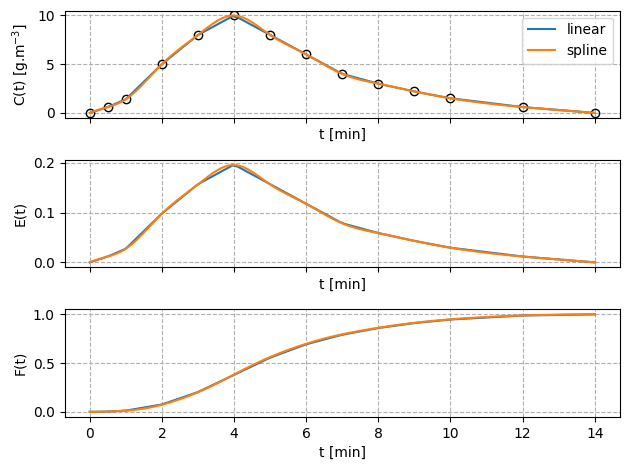

In [19]:
ti = np.linspace(0, 14, 100)

fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, sharex=True)
# Curva C(t)
ax0.plot(t, C, marker='o', ls='', c='k', mfc='None')
ax0.plot(ti, Ci(ti), label='linear')
ax0.plot(ti, Cs(ti), label='spline')
ax0.set_ylabel(r"C(t) [g.m$^{-3}$]")
ax0.legend()
# Curva E(t)
ax1.plot(ti, Ei(ti))
ax1.plot(ti, Es(ti))
ax1.set_ylabel(r"E(t)")
# Curva F(t)
ax2.plot(ti, Fi(ti))
ax2.plot(ti, Fs(ti))
ax2.set_ylabel(r"F(t)")
for ax in (ax0, ax1, ax2):
    ax.set_xlabel(r"t [min]")
    ax.grid(ls='--')
fig.tight_layout()
plt.show()

### 1.4.2 Ejemplo

    Levenspiel, Ex. 11.1

In [20]:
t = np.array([0, 5, 10, 15, 20, 25, 30, 35]) # min
C = np.array([0, 3, 5, 5, 4, 2, 1, 0]) # g/dm3

**Interpolación e integración:**

In [21]:
# Curva C(t)
Ci = interp1d(t, C, kind='linear') # linear
Cs = CubicSpline(t, C) # spline
# Curva E(t)
Ei = interp1d(t, Ci(t)/trapezoid(Ci(t),t)) # linear
Es = CubicSpline(t, Cs(t)/Cs.integrate(t[0], t[-1])) # spline
# Curva F(t)
Fi = interp1d(t, cumulative_trapezoid(Ei(t), t, initial=0)) # linear
Fs = Es.antiderivative() # spline

print(10*' ', "Linear   Splines")
print(f"∫ C(t)dt = {trapezoid(Ci(t),t):8.4f} | {Cs.integrate(t[0], t[-1]):8.4f} [g.s/m3]")
print(f"∫ E(t)dt = {trapezoid(Ei(t),t):.4f} | {Es.integrate(t[0], t[-1]):.4f}")

           Linear   Splines
∫ C(t)dt = 100.0000 | 101.9189 [g.s/m3]
∫ E(t)dt = 1.0000 | 1.0000


**Comparación gráfica:**

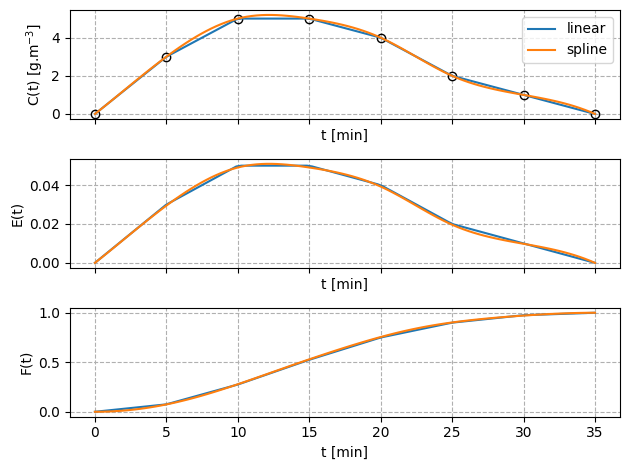

In [22]:
ti = np.linspace(0, 35, 100)

fig, (ax0, ax1, ax2) = plt.subplots(nrows=3, sharex=True)
# Curva C(t)
ax0.plot(t, C, marker='o', ls='', c='k', mfc='None')
ax0.plot(ti, Ci(ti), label='linear')
ax0.plot(ti, Cs(ti), label='spline')
ax0.set_ylabel(r"C(t) [g.m$^{-3}$]")
ax0.legend()
# Curva E(t)
ax1.plot(ti, Ei(ti))
ax1.plot(ti, Es(ti))
ax1.set_ylabel(r"E(t)")
# Curva F(t)
ax2.plot(ti, Fi(ti))
ax2.plot(ti, Fs(ti))
ax2.set_ylabel(r"F(t)")
for ax in (ax0, ax1, ax2):
    ax.set_xlabel(r"t [min]")
    ax.grid(ls='--')
fig.tight_layout()
plt.show()

### 1.4.3 Comentarios sobre interpolación

Regla de oro:



<div class="alert alert-warning">

$$\text{Interpolación } \ne \text{ Extrapolación}$$

</div>


#### 1.4.3.1 Interpolación con `interp1d`

La [documentación](https://docs.scipy.org/doc/scipy/reference/generated/scipy.interpolate.interp1d.html#scipy.interpolate.interp1d) recomienda usar otras alternativas [mas modernas](https://docs.scipy.org/doc/scipy/tutorial/interpolate/1D.html#tutorial-interpolate-1dsection).

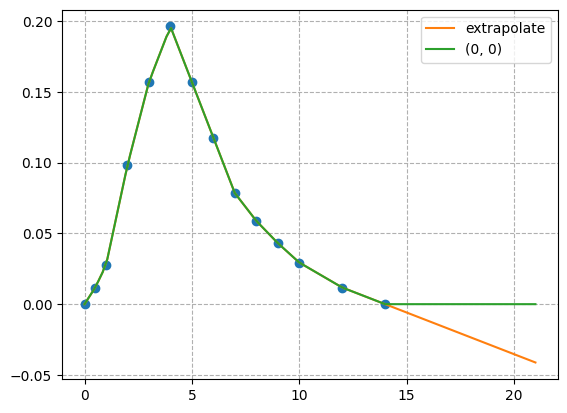

In [23]:
t = np.array([0, 0.5, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14]) # min
C = np.array([0, 0.6, 1.4, 5, 8, 10, 8, 6, 4, 3, 2.2, 1.5, 0.6, 0]) # g/m3
integral = trapezoid(C, t)

fig, ax = plt.subplots()
ax.plot(t, C/integral, ls='', marker='o')
tt = np.linspace(0, 21, 100)

fill_values = ["extrapolate", (0,0)]
for fill_value in fill_values:
    Ei = interp1d(t, C/integral, kind='linear', bounds_error=False, fill_value=fill_value)     # E(t) 
    ax.plot(tt, Ei(tt), label=f'{fill_value}')
ax.grid(ls='--')
ax.legend()
plt.show()

#### 1.4.3.2 Interpolación con `CubicSpline`

El uso de `CubicSpline` se puede consultar en la [Documentación](https://docs.scipy.org/doc//scipy-1.9.0/reference/generated/scipy.interpolate.CubicSpline.html). Notese la forma de la curva fuera del dominio de intepolación, y cómo varía en función del tipo de condición a la frontera, `bc_type`.

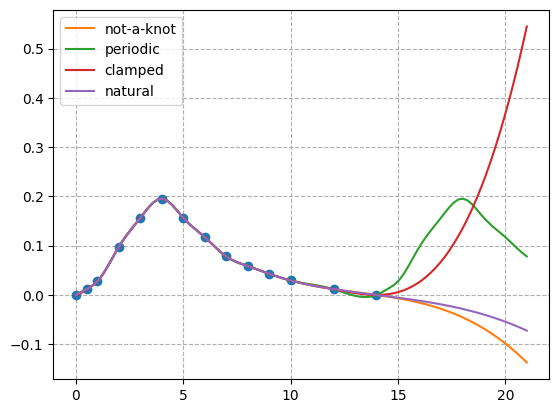

In [24]:
t = np.array([0, 0.5, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14]) # min
C = np.array([0, 0.6, 1.4, 5, 8, 10, 8, 6, 4, 3, 2.2, 1.5, 0.6, 0]) # g/m3
integral = CubicSpline(t, C) .integrate(t[0], t[-1])

fig, ax = plt.subplots()
ax.plot(t, C/integral, ls='', marker='o')
tt = np.linspace(0, 21, 100)

bc_types = ["not-a-knot", "periodic", "clamped", "natural"]
for bc_type in bc_types:
    Es = CubicSpline(t, C/integral, bc_type=bc_type)     # E(t) spline
    ax.plot(tt, Es(tt), label=f'{bc_type}')
ax.grid(ls='--')
ax.legend()
plt.show()

Es posible anclar las fronteras usando una condición a la frontera `bc_type='clampled'`, y  [agregando nodos suplemementarios en las fronteras](https://docs.scipy.org/doc/scipy/tutorial/interpolate/extrapolation_examples.html).

In [25]:
def add_boundary_knots(spline):
    """
    Add knots infinitesimally to the left and right.

    Additional intervals are added to have zero 2nd and 3rd derivatives,
    and to maintain the first derivative from whatever boundary condition
    was selected. The spline is modified in place.
    """
    # determine the slope at the left edge
    leftx = spline.x[0]
    lefty = spline(leftx)
    leftslope = spline(leftx, nu=1)

    # add a new breakpoint just to the left and use the
    # known slope to construct the PPoly coefficients.
    leftxnext = np.nextafter(leftx, leftx - 1)
    leftynext = lefty + leftslope*(leftxnext - leftx)
    leftcoeffs = np.array([0, 0, leftslope, leftynext])
    spline.extend(leftcoeffs[..., None], np.r_[leftxnext])

    # repeat with additional knots to the right
    rightx = spline.x[-1]
    righty = spline(rightx)
    rightslope = spline(rightx,nu=1)
    rightxnext = np.nextafter(rightx, rightx + 1)
    rightynext = righty + rightslope * (rightxnext - rightx)
    rightcoeffs = np.array([0, 0, rightslope, rightynext])
    spline.extend(rightcoeffs[..., None], np.r_[rightxnext])


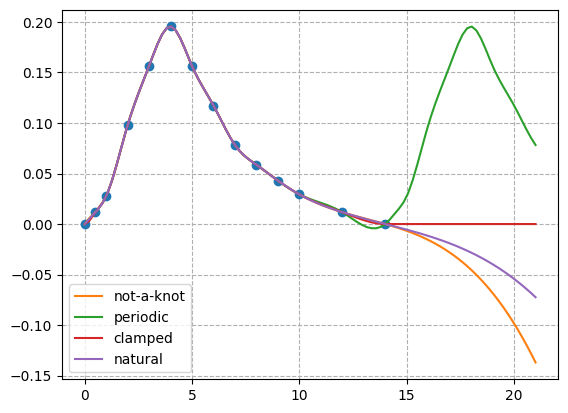

In [26]:
t = np.array([0, 0.5, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 12, 14]) # min
C = np.array([0, 0.6, 1.4, 5, 8, 10, 8, 6, 4, 3, 2.2, 1.5, 0.6, 0]) # g/m3
integral = CubicSpline(t, C) .integrate(t[0], t[-1])

fig, ax = plt.subplots()
ax.plot(t, C/integral, ls='', marker='o')
tt = np.linspace(0, 21, 100)

bc_types = ["not-a-knot", "periodic", "clamped", "natural"]
for bc_type in bc_types:
    Es = CubicSpline(t, C/integral, bc_type=bc_type)     # E(t) spline
    if bc_type == "clamped":
        add_boundary_knots(Es)
    ax.plot(tt, Es(tt), label=f'{bc_type}')
ax.grid(ls='--')
ax.legend()
plt.show()